In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "scikit-learn"])


0

In [5]:
import math
import pandas as pd
import numpy as np
from operator import itemgetter


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics


from sklearn import tree
from sklearn.tree import _tree

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

In [7]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
INFILE = "C:\\Users\\dchee\\OneDrive\\Documents\\Grad School\\MSDS 422 - Machine Learning\\Module 1\\hmeq_assignment_1.csv"

df = pd.read_csv(INFILE)

In [50]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TARGET_BAD_FLAG,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
TARGET_LOSS_AMT,1189.0,13414.576955,10839.455965,224.000000,5639.000000,11003.000000,17634.000000,78987.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
z_IMP_JOB_MISSING,5960.0,0.046812,0.211254,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Mgr,5960.0,0.128691,0.334886,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Office,5960.0,0.159060,0.365763,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Other,5960.0,0.400671,0.490076,0.000000,0.000000,0.000000,1.000000,1.000000
z_IMP_JOB_Sales,5960.0,0.018289,0.134004,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_ProfExe,5960.0,0.214094,0.410227,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Self,5960.0,0.032383,0.177029,0.000000,0.000000,0.000000,0.000000,1.000000


In [51]:
## Find the variables that are objects, integers, and floats. Put them in a list.

# print(df.dtypes)
dt = df.dtypes
print(dt)
# print(df.describe().T)

objList = []
intList = []
floatList = []


TARGET_F = "TARGET_BAD_FLAG"
TARGET_A = "TARGET_LOSS_AMT"

for i in dt.index:
    # print(" here is i ....", i, ".... and here is the type", dt[i])
    if i in ( [TARGET_F, TARGET_A] ): continue
    if dt[i] in (["object"]) : objList.append(i)
    if dt[i] in (["float64"]) : floatList.append(i)
    if dt[i] in (["int64"]) : intList.append(i)

# print(" OBJECTS ")
# print('  ------ ')
# for i in objList:
#     print(i)
# print(" INTEGERS ")
# print('  ------ '\n)
# for i in intList:
#     print(i)
# print(" FLOAT ")
# print('  ------ ')
# for i in floatList:
#     print(i)


### Explore the Categorical / Object Variables
# for i in objList:
#         print(" Class = ", i)
#         g = df.groupby(i)
#         # print(g[i].count())
#         x = g[TARGET_F].mean()
#         print('Loan Owed = ', x)
#         print(" ---------- ")
#         x = g[TARGET_A].mean()
#         print('Remaining  Amount = ', x)
#         print(' =============\n\n\n')




TARGET_BAD_FLAG           int64
TARGET_LOSS_AMT         float64
LOAN                      int64
z_IMP_JOB_MISSING         int64
z_IMP_JOB_Mgr             int64
z_IMP_JOB_Office          int64
z_IMP_JOB_Other           int64
z_IMP_JOB_Sales           int64
z_IMP_JOB_ProfExe         int64
z_IMP_JOB_Self            int64
z_IMP_REASON_MISSING      int64
z_IMP_REASON_HomeImp      int64
z_IMP_REASON_DebtCon      int64
M_MORTDUE                 int64
IMP_MORTDUE             float64
M_VALUE                   int64
IMP_VALUE               float64
M_YOJ                     int64
IMP_YOJ                 float64
M_DEROG                   int64
IMP_DEROG               float64
M_DELINQ                  int64
IMP_DELINQ              float64
M_CLAGE                   int64
IMP_CLAGE               float64
M_NINQ                    int64
IMP_NINQ                float64
M_CLNO                    int64
IMP_CLNO                float64
M_DEBTINC                 int64
IMP_DEBTINC             float64
dtype: o

In [91]:

X = df.copy()
X = X.drop( TARGET_F, axis=1 )
X = X.drop( TARGET_A, axis=1 )
##
Y = df[ [TARGET_F, TARGET_A] ]
#
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=1)
##X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, test_size=0.2 ) ## without random_state, uses system clock to generate random number each run
##
print( "FLAG DATA" )
print( "TRAINING = ", X_train.shape )
print( "TEST = ", X_test.shape )
##
## Flag Variable - filtering where amount is NOT null
F = ~ Y_train[ TARGET_A ].isna()

### Subsetting the Flag will filter W & Z to only records where the Loan defaulted
W_train = X_train[F].copy()
Z_train = Y_train[F].copy()

## Same but for test data set
F = ~ Y_test[ TARGET_A ].isna()
W_test = X_test[F].copy()
Z_test = Y_test[F].copy()

##print( Z_train.describe() )
##print( Z_test.describe() )
##print( "\n\n")
##
##F = Z_train[ TARGET_A ] > 25000
##Z_train.loc[ F, TARGET_A ] = 25000
##
##F = Z_test[ TARGET_A ] > 25000
##Z_test.loc[ F, [TARGET_A] ] = 25000
##
##print( Z_train.describe() )
##print( Z_test.describe() )
##print( "\n\n")
##
##
##print( " ====== ")
##
##print( "AMOUNT DATA" )
##print( "TRAINING = ", W_train.shape )
##print( "TEST = ", Z_test.shape )


FLAG DATA
TRAINING =  (4768, 29)
TEST =  (1192, 29)


In [85]:


"""
DECISION TREE
"""

def getTreeVars( TREE, varNames ) :
   tree_ = TREE.tree_
   varName = [ varNames[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature ]

   nameSet = set()
   for i in tree_.feature :
       if i != _tree.TREE_UNDEFINED :
           nameSet.add( i )
   nameList = list( nameSet )
   parameter_list = list()
   for i in nameList :
       parameter_list.append( varNames[i] )
   return parameter_list

vars_tree_flag = getTreeVars( fm01_Tree, feature_cols )
for i in vars_tree_flag:
        print(i)


M_VALUE
IMP_VALUE
IMP_YOJ
M_DEROG
IMP_DEROG
IMP_DELINQ
IMP_CLAGE
M_DEBTINC
IMP_DEBTINC




DECISION TREE

Probability of crash
Accuracy Train: 0.8928271812080537
Accuracy Test: 0.8875838926174496




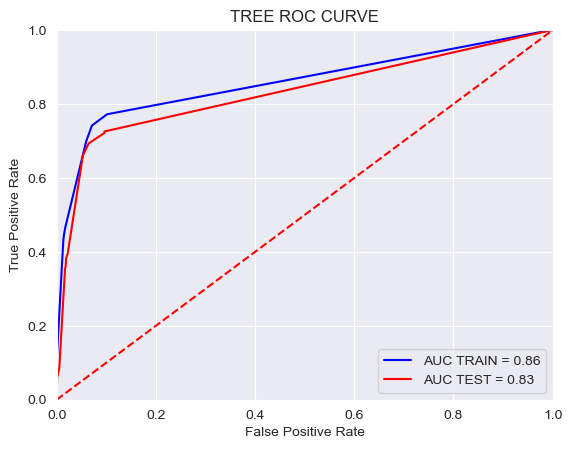

In [86]:
# # CRASH PROBABILITY
#
fm01_Tree = tree.DecisionTreeClassifier( max_depth=4 )
fm01_Tree = fm01_Tree.fit( X_train, Y_train[ TARGET_F ] )
# ##
Y_Pred_train = fm01_Tree.predict(X_train)
Y_Pred_test = fm01_Tree.predict(X_test)
# ##
# ##
# print("\n=============\n")
# print("DECISION TREE\n")
# print("Probability of crash")
# print("Accuracy Train:",metrics.accuracy_score(Y_train[TARGET_F], Y_Pred_train))
# print("Accuracy Test:",metrics.accuracy_score(Y_test[TARGET_F], Y_Pred_test))
# print("\n")
# ##
# ##
probs = fm01_Tree.predict_proba(X_train)
p1 = probs[:,1]
fpr_train, tpr_train, threshold = metrics.roc_curve( Y_train[TARGET_F], p1)
roc_auc_train = metrics.auc(fpr_train, tpr_train)
##
probs = fm01_Tree.predict_proba(X_test)
p1 = probs[:,1]
fpr_test, tpr_test, threshold = metrics.roc_curve( Y_test[TARGET_F], p1)
roc_auc_test = metrics.auc(fpr_test, tpr_test)
# #
fpr_tree = fpr_test
tpr_tree = tpr_test
auc_tree = roc_auc_test
#
#
plt.title('TREE ROC CURVE')
plt.plot(fpr_train, tpr_train, label = 'AUC TRAIN = %0.2f' % roc_auc_train, color="blue")
plt.plot(fpr_test, tpr_test, label = 'AUC TEST = %0.2f' % roc_auc_test, color="red" )
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
# ##
# ##
feature_cols = list( X.columns.values )
tree.export_graphviz(fm01_Tree,out_file='tree_f.txt',filled=True, rounded=True, feature_names = feature_cols, impurity=False, class_names=["Good","Bad"]  )
vars_tree_flag = getTreeVars( fm01_Tree, feature_cols )
#
#
# ### Overall probability of loan defaulting is high

In [78]:
"""
DECISION TREE
"""

def getTreeVars( TREE, varNames ) :
   tree_ = TREE.tree_
   varName = [ varNames[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature ]

   nameSet = set()
   for i in tree_.feature :
       if i != _tree.TREE_UNDEFINED :
           nameSet.add( i )
   nameList = list( nameSet )
   parameter_list = list()
   for i in nameList :
       parameter_list.append( varNames[i] )
   return parameter_list

vars_tree_flag = getTreeVars( fm01_Tree, feature_cols )



In [97]:
# DAMAGES

amt_m01_Tree = tree.DecisionTreeRegressor( max_depth= 4 )
amt_m01_Tree = amt_m01_Tree.fit( W_train, Z_train[TARGET_A] )

Z_Pred_train = amt_m01_Tree.predict(W_train)
Z_Pred_test = amt_m01_Tree.predict(W_test)

##print( "MEAN Train", Z_train[TARGET_A].mean() )
##print( "MEAN Test", Z_test[TARGET_A].mean() )
##print( " ----- \n\n" )
##
RMSE_TRAIN = math.sqrt( metrics.mean_squared_error(Z_train[TARGET_A], Z_Pred_train))
RMSE_TEST = math.sqrt( metrics.mean_squared_error(Z_test[TARGET_A], Z_Pred_test))
##
print("TREE RMSE Train:", RMSE_TRAIN )
print("TREE RMSE Test:", RMSE_TEST )
##
RMSE_TREE = RMSE_TEST
#
feature_cols = list( X.columns.values )
vars_tree_amt = getTreeVars( amt_m01_Tree, feature_cols )
tree.export_graphviz(amt_m01_Tree,out_file='tree_a.txt',filled=True, rounded=True, feature_names = feature_cols, impurity=False, precision=0  )

print("\n")
for i in vars_tree_amt :
   print(i)


##print( "FLAG=",vars_tree_flag )
##print(" ==== \n\n")
##print( "AMOUNT=",vars_tree_amt )


TREE RMSE Train: 4561.00912099753
TREE RMSE Test: 5732.6842719501765


LOAN
z_IMP_REASON_DebtCon
IMP_MORTDUE
IMP_NINQ
IMP_CLNO
M_DEBTINC
IMP_DEBTINC


## Random Forest

In [114]:

def getEnsembleTreeVars( ENSTREE, varNames ) :
   importance = ENSTREE.feature_importances_
   index = np.argsort(importance)
   theList = []
   for i in index :
       imp_val = importance[i]
       if imp_val > np.average( ENSTREE.feature_importances_ ) :
           v = int( imp_val / np.max( ENSTREE.feature_importances_ ) * 100 )
           theList.append( ( varNames[i], v ) )
   theList = sorted(theList,key=itemgetter(1),reverse=True)
   return theList



fm01_RF = RandomForestClassifier( n_estimators = 25, random_state=1 )
fm01_RF = fm01_RF.fit( X_train, Y_train[ TARGET_F ] )

Y_Pred_train = fm01_RF.predict(X_train)
Y_Pred_test = fm01_RF.predict(X_test)

print("\n=============\n")
print("RANDOM FOREST\n")
print("Probability of crash")
print("Accuracy Train:",metrics.accuracy_score(Y_train[TARGET_F], Y_Pred_train))
print("Accuracy Test:",metrics.accuracy_score(Y_test[TARGET_F], Y_Pred_test))
print("\n")

probs = fm01_RF.predict_proba(X_train)
p1 = probs[:,1]
fpr_train, tpr_train, threshold = metrics.roc_curve( Y_train[TARGET_F], p1)
roc_auc_train = metrics.auc(fpr_train, tpr_train)

probs = fm01_RF.predict_proba(X_test)
p1 = probs[:,1]
fpr_test, tpr_test, threshold = metrics.roc_curve( Y_test[TARGET_F], p1)
roc_auc_test = metrics.auc(fpr_test, tpr_test)

fpr_RF = fpr_test
tpr_RF = tpr_test
auc_RF = roc_auc_test


# feature_cols = list( X.columns.values )
# vars_RF_flag = getEnsembleTreeVars( fm01_RF, feature_cols )
#
# for i in vars_RF_flag :
#    print( i )

# plt.title('RF ROC CURVE')
# plt.plot(fpr_train, tpr_train, label = 'AUC TRAIN = %0.2f' % roc_auc_train, color="blue")
# plt.plot(fpr_test, tpr_test, label = 'AUC TEST = %0.2f' % roc_auc_test, color="red")
# plt.legend(loc = 'lower right')
# plt.plot([0, 1], [0, 1],'r--')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
# plt.ylabel('True Positive Rate')
# plt.xlabel('False Positive Rate')
# plt.show()


amt_m01_RF = RandomForestRegressor(n_estimators = 100, random_state=1)
amt_m01_RF = amt_m01_RF.fit( W_train, Z_train[TARGET_A] )

Z_Pred_train = amt_m01_RF.predict(W_train)
Z_Pred_test = amt_m01_RF.predict(W_test)

RMSE_TRAIN = math.sqrt( metrics.mean_squared_error(Z_train[TARGET_A], Z_Pred_train))
RMSE_TEST = math.sqrt( metrics.mean_squared_error(Z_test[TARGET_A], Z_Pred_test))

print("RF RMSE Train:", RMSE_TRAIN )
print("RF RMSE Test:", RMSE_TEST )

RMSE_RF = RMSE_TEST

feature_cols = list( X.columns.values )
vars_RF_amt = getEnsembleTreeVars( amt_m01_RF, feature_cols )

for i in vars_RF_amt :
   print( i )



RANDOM FOREST

Probability of crash
Accuracy Train: 0.9993708053691275
Accuracy Test: 0.9177852348993288


RF RMSE Train: 832.3683361182497
RF RMSE Test: 2166.5254588204907
('LOAN', 100)
('IMP_CLNO', 13)
('IMP_DEBTINC', 10)
('M_DEBTINC', 5)


## Gradient Boosting

In [116]:
"""
GRADIENT BOOSTING
"""


fm01_GB = GradientBoostingClassifier( random_state=1 )
fm01_GB = fm01_GB.fit( X_train, Y_train[ TARGET_F ] )

Y_Pred_train = fm01_GB.predict(X_train)
Y_Pred_test = fm01_GB.predict(X_test)
##
print("\n=============\n")
print("GRADIENT BOOSTING\n")
print("Probability of crash")
print("Accuracy Train:",metrics.accuracy_score(Y_train[TARGET_F], Y_Pred_train))
print("Accuracy Test:",metrics.accuracy_score(Y_test[TARGET_F], Y_Pred_test))
print("\n")

probs = fm01_GB.predict_proba(X_train)
p1 = probs[:,1]
fpr_train, tpr_train, threshold = metrics.roc_curve( Y_train[TARGET_F], p1)
roc_auc_train = metrics.auc(fpr_train, tpr_train)

probs = fm01_GB.predict_proba(X_test)
p1 = probs[:,1]
fpr_test, tpr_test, threshold = metrics.roc_curve( Y_test[TARGET_F], p1)
roc_auc_test = metrics.auc(fpr_test, tpr_test)

fpr_GB = fpr_test
tpr_GB = tpr_test
auc_GB = roc_auc_test


feature_cols = list( X.columns.values )
vars_GB_flag = getEnsembleTreeVars( fm01_GB, feature_cols )


for i in vars_GB_flag :
   print(i)
##
##
# ##
# plt.title('GB ROC CURVE')
# plt.plot(fpr_train, tpr_train, label = 'AUC TRAIN = %0.2f' % roc_auc_train, color="blue")
# plt.plot(fpr_test, tpr_test, label = 'AUC TEST = %0.2f' % roc_auc_test, color="red")
# plt.legend(loc = 'lower right')
# plt.plot([0, 1], [0, 1],'r--')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
# plt.ylabel('True Positive Rate')
# plt.xlabel('False Positive Rate')
# plt.show()
##
##
##
##
##
amt_m01_GB = GradientBoostingRegressor(random_state=1)
amt_m01_GB = amt_m01_GB.fit( W_train, Z_train[TARGET_A] )

Z_Pred_train = amt_m01_GB.predict(W_train)
Z_Pred_test = amt_m01_GB.predict(W_test)

RMSE_TRAIN = math.sqrt( metrics.mean_squared_error(Z_train[TARGET_A], Z_Pred_train))
RMSE_TEST = math.sqrt( metrics.mean_squared_error(Z_test[TARGET_A], Z_Pred_test))

print("GB RMSE Train:", RMSE_TRAIN )
print("GB RMSE Test:", RMSE_TEST )

RMSE_GB = RMSE_TEST

feature_cols = list( X.columns.values )
vars_GB_amt = getEnsembleTreeVars( amt_m01_GB, feature_cols )


for i in vars_GB_amt :
   print(i)



GRADIENT BOOSTING

Probability of crash
Accuracy Train: 0.9234479865771812
Accuracy Test: 0.9043624161073825


('M_DEBTINC', 100)
('IMP_DEBTINC', 29)
('IMP_DELINQ', 19)
('IMP_CLAGE', 14)
('IMP_DEROG', 7)
GB RMSE Train: 1046.8411799363107
GB RMSE Test: 1834.275026502114
('LOAN', 100)
('IMP_CLNO', 16)
('IMP_DEBTINC', 8)
('M_DEBTINC', 7)
('IMP_CLAGE', 5)


## Model ROC

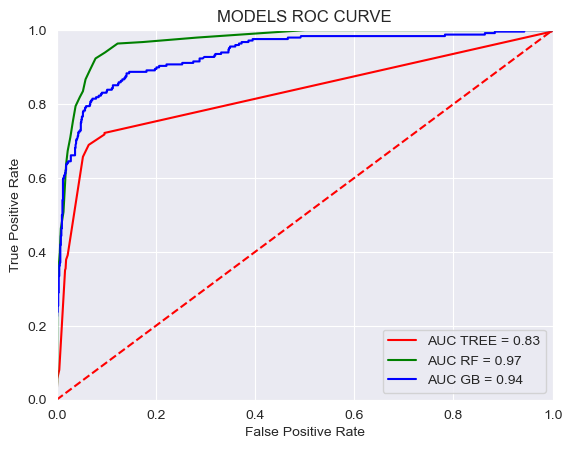

Root Mean Square Average For Damages
TREE 3942.9974837311943
RF 2166.5254588204907
GB 1834.275026502114


In [117]:

plt.title('MODELS ROC CURVE')
plt.plot(fpr_tree, tpr_tree, label = 'AUC TREE = %0.2f' % auc_tree, color="red")
plt.plot(fpr_RF, tpr_RF, label = 'AUC RF = %0.2f' % auc_RF, color="green")
plt.plot(fpr_GB, tpr_GB, label = 'AUC GB = %0.2f' % auc_GB, color="blue")
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
##
##
##
print("Root Mean Square Average For Damages")
print("TREE", RMSE_TREE)
print("RF", RMSE_RF)
print("GB", RMSE_GB)